
🤖 Assistant
The weather in Chennai is sunny with a high of 32 degrees Celsius and a low of 24 degrees Celsius. The price of the Rajesh 4-star hotel is 32000 rs per person. There are Indigo flights available from Monday to Friday.


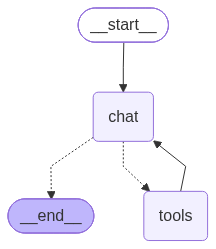

In [3]:
import os
import getpass
from langchain_groq import ChatGroq
from langchain_core.tools import tool
from langgraph.prebuilt import tools_condition,ToolNode
from langgraph.graph import StateGraph,START,END,MessagesState
from IPython.display import display,Image
#Get api key
os.environ["GROQ_API_KEY"] = getpass.getpass("Enter your groq api key : ")

# llm Initialisation

llm = ChatGroq(
    model = "llama-3.3-70b-versatile",
    api_key = os.environ["GROQ_API_KEY"]
)

#Tool Creation

@tool
def get_weather(city : str) -> str:
    """returns weather of the requested city"""
    
    weather = {
        "chennai" : "hot",
        "hyderabad" : "cold",
        "kerala" : "breezy"
    }
    return weather.get(city.lower(),f"No data availabe for {city}")

@tool
def book_hotel(hotel_name : str) -> str:
    """book hotel of the provided hotel name"""
    
    hotels = {
        "raash 5 star hotel" : "50000 rs per person",
        "rajesh 4 star hotel" : "32000 rs per person",
        "jamalia 3 star hotel" : "10000 rs per person"
    }
    
    return hotels.get(hotel_name.lower(),f"No hotel available")

@tool 
def book_flight(flight_name : str) -> str:
    """Book flight for the flight name provided"""
    
    flights = {
        "indigo": "Flights available from monday to friday",
        "air india" : "only available on sunday",
        "emirates" : "All days available"
    }
    return flights.get(flight_name.lower(),f"No flights available")

# grouping tools

tools = [get_weather,book_hotel,book_flight]

#binding the tools with llm

llm_with_tools = llm.bind_tools(tools)

#define chat bot

def chat_bot(state : MessagesState):
    
    query = state["messages"]
    response = llm_with_tools.invoke(query)
    return {
        "messages" : response
    }
    
#creating Node for the tools

tool_node = ToolNode(tools)

#Build the graph

builder = StateGraph(MessagesState)
builder.add_node("chat",chat_bot)
builder.add_node("tools",tool_node)

builder.add_edge(START,"chat")
builder.add_conditional_edges(
    "chat",
    tools_condition
)
builder.add_edge("tools","chat")

graph = builder.compile()
question = "I'm going to Chennai tomorrow.Check the weather and check rate of the Rajesh 4 star hotel and find any available Indigo flight for tomorrow"
res = graph.invoke({
    "messages" : HumanMessage(content=question)
})

print("\n" + "=" * 50)
print("🤖 Assistant")
print("=" * 50)
print(res["messages"][-1].content)

display(
    Image(
        graph.get_graph().draw_mermaid_png()
    )
)